In [209]:
# Import
# !pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data
df = pd.read_csv('../data/ff1_spells.csv', encoding='latin-1')
df.head()

,name,level,mp,power,accuracy,element,target,price,location,job,ninja,knight,red mage,red wizard,white mage,white wizard,black mage,black wizard
0,Fire,1,5,10,24,Fire,One enemy,100,Cornelia,"Ni, RM, RW, BM, BW",1,0,1,1,0,0,1,1
1,Thunder,1,5,10,24,Lightning,One enemy,100,Cornelia,"Ni, RM, RW, BM, BW",1,0,1,1,0,0,1,1
2,Focus,1,3,20,64,,One enemy,100,Cornelia,"Ni, RM, RW, BM, BW",1,0,1,1,0,0,1,1
3,Sleep,1,3,0,24,Status,All enemies,100,Cornelia,"Ni, RM, RW, BM, BW",1,0,1,1,0,0,1,1
4,Dark,2,5,0,24,Status,All enemies,400,Pravoka,"Ni, RM, RW, BM, BW",1,0,1,1,0,0,1,1


In [210]:
# Remove all features except the following: level, mp, power, accuracy, target, price
df = df[['level', 'mp', 'power', 'accuracy', 'target', 'price']]
df.head()

,level,mp,power,accuracy,target,price
0,1,5,10,24,One enemy,100
1,1,5,10,24,One enemy,100
2,1,3,20,64,One enemy,100
3,1,3,0,24,All enemies,100
4,2,5,0,24,All enemies,400


<Axes: ylabel='Frequency'>

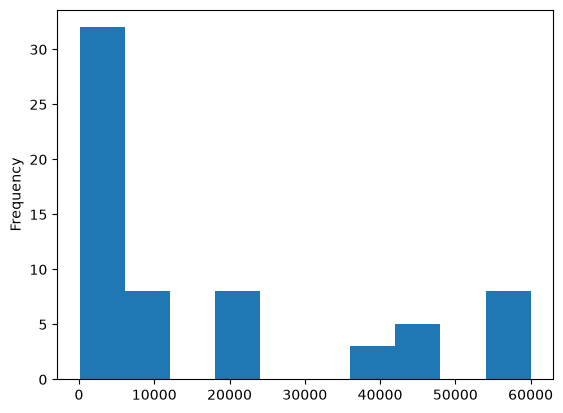

In [211]:
# Draw histogram for 'price' feature
df['price'].plot(kind='hist')

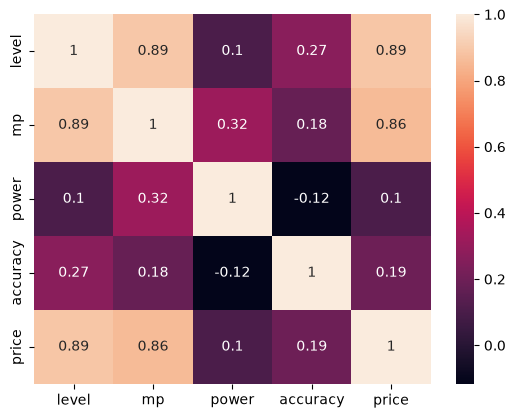

In [212]:
# Draw a correlation plot
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

In [213]:
# Categorical Encode 'target' by encoding to a one hot array
from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
one_hot = enc.fit_transform(df['target'])

# Use PCA to convert the one hot to a single dimension
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
df['target_enc'] = pca.fit_transform(one_hot)
print(f'variance explained: {pca.explained_variance_ratio_}')

# Add this to the dataframe, remove the original 'target' feature
df = df.drop(columns=['target'])
df.head()

variance explained: [0.41613412]


,level,mp,power,accuracy,price,target_enc
0,1,5,10,24,100,-0.297816
1,1,5,10,24,100,-0.297816
2,1,3,20,64,100,-0.297816
3,1,3,0,24,100,0.719371
4,2,5,0,24,400,0.719371


In [214]:
# Determine how many outliers exist in the data, use entire df at this point
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs
clf = LocalOutlierFactor(n_neighbors=5)
df['outlier'] = clf.fit_predict(df)
print(df['outlier'].value_counts())

outlier
 1    58
-1     6
Name: count, dtype: int64


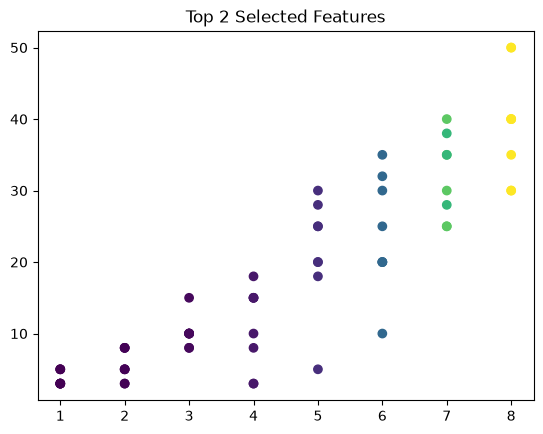

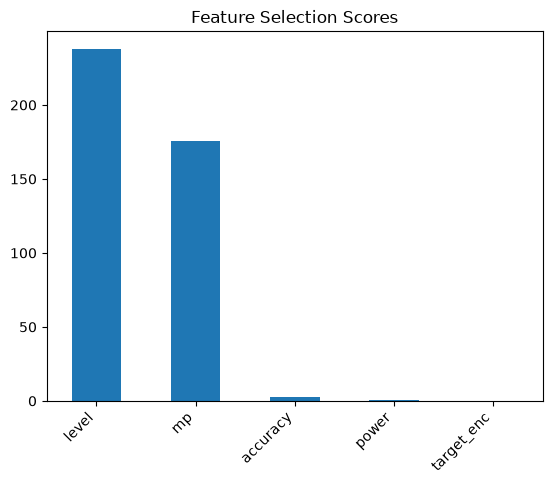

In [215]:
# Separate into X and y components (price is our output in this example, remaining features are input)
df = df.drop(columns=['outlier'])
X = df.drop(columns=['price'])
y = df['price']

# Use feature selection to determine which features would be best to use for the model
from sklearn.feature_selection import SelectKBest, f_regression
kselect = SelectKBest(k=2, score_func=f_regression)
X_best = kselect.fit_transform(X, y)

# graph 1
plt.scatter(X_best[:,0], X_best[:,1], c=y)
plt.title('Top 2 Selected Features')
plt.show()

# graph 2
scores = pd.Series(kselect.scores_, index=X.columns)
scores.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Selection Scores')
plt.xticks(rotation=45, ha='right')
plt.show()


In [216]:
# Create a dummy regressor, fit the model with X and y
from sklearn.dummy import DummyRegressor
dr = DummyRegressor()
dr.fit(X,y)

# Predict the price of a spell with the following [1, 5, 20, 50, 0.5]
print(dr.predict([[1, 5, 20, 50, 0.5]]))
print(dr.score(X,y))

[17140.625]
0.0


In [217]:
# Any missing or invalid data
print(df['level'].isna().sum())
print(df['mp'].isna().sum())
print(df['accuracy'].isna().sum())
print(df['power'].isna().sum())
print(df['target_enc'].isna().sum())

0
0
0
0
0


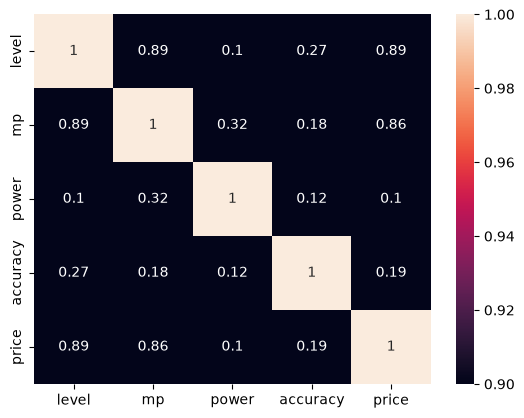

In [218]:
# check coliearity
corr = corr.abs()
sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
plt.show()